In [1]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/")
library(data.table)
library(ggplot2)

In [2]:
d <- fread("data/post_hoc/results/pLoF_damaging_missense_maf0to5e-2_knockouts_by_genes.txt.gz")
head(d[ d$`CHET-TRANS` > 0 | d$HOM > 0, ])

hgnc_symbol,ensembl_gene_id,CHET-CIS,CHET-TRANS,CHET-UNKNOWN,HET,HOM
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>
CFTR,ENSG00000001626,24,117,2,8348,4
SLC7A2,ENSG00000003989,3,14,3,3056,3
SARM1,ENSG00000004139,0,0,1,1592,2
RECQL,ENSG00000004700,0,3,0,1319,0
ABCB5,ENSG00000004846,609,56,3,6175,13
SLC4A1,ENSG00000004939,0,2,1,1194,0


In [3]:
d[d$hgnc_symbol %in% "MUTYH",]

hgnc_symbol,ensembl_gene_id,CHET-CIS,CHET-TRANS,CHET-UNKNOWN,HET,HOM
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>
MUTYH,ENSG00000132781,2,18,2,3773,12


In [6]:
d <- fread("data/knockouts/alt/ukb_eur_wes_200k_chr1_maf0to5e-2_pLoF_damaging_missense_all.tsv.gz")

In [7]:
d[d$gene_id %in% "ENSG00000132781" & pKO > 0, ]

gene_id,s,gts,varid,hom_alt_n,phased.a1,phased.a2,unphased.n,pKO,knockout
<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<chr>
ENSG00000132781,1625904,"[""1|1""]","[""chr1:45331556:C:T""]",1,0,0,0,1.0,Homozygote
ENSG00000132781,1760693,"[""1|0"",""0|1""]","[""chr1:45331556:C:T"",""chr1:45332479:C:T""]",0,1,1,0,1.0,Compound heterozygote
ENSG00000132781,2027668,"[""1|0"",""0|1""]","[""chr1:45331556:C:T"",""chr1:45332803:T:C""]",0,1,1,0,1.0,Compound heterozygote
ENSG00000132781,2098108,"[""0|1"",""1|0""]","[""chr1:45331556:C:T"",""chr1:45332479:C:T""]",0,1,1,0,1.0,Compound heterozygote
ENSG00000132781,2204052,"[""1|0"",""0|1""]","[""chr1:45331556:C:T"",""chr1:45332803:T:C""]",0,1,1,0,1.0,Compound heterozygote
ENSG00000132781,2464180,"[""1|1""]","[""chr1:45331556:C:T""]",1,0,0,0,1.0,Homozygote
ENSG00000132781,2510784,"[""1|1""]","[""chr1:45331556:C:T""]",1,0,0,0,1.0,Homozygote
ENSG00000132781,2711887,"[""1|1""]","[""chr1:45331556:C:T""]",1,0,0,0,1.0,Homozygote
ENSG00000132781,2909473,"[""0|1"",""1|0""]","[""chr1:45331228:G:A"",""chr1:45331556:C:T""]",0,1,1,0,1.0,Compound heterozygote


In [27]:
dt <- as.data.table(table(d$knockout, d$gene_id))
colnames(dt) <- c("knockout","gene_id","n")

In [24]:
samples <- length(unique(d$s))

In [28]:
dt$f <- dt$n / samples

Warning message:
"Removed 2915 rows containing non-finite values (stat_density)."


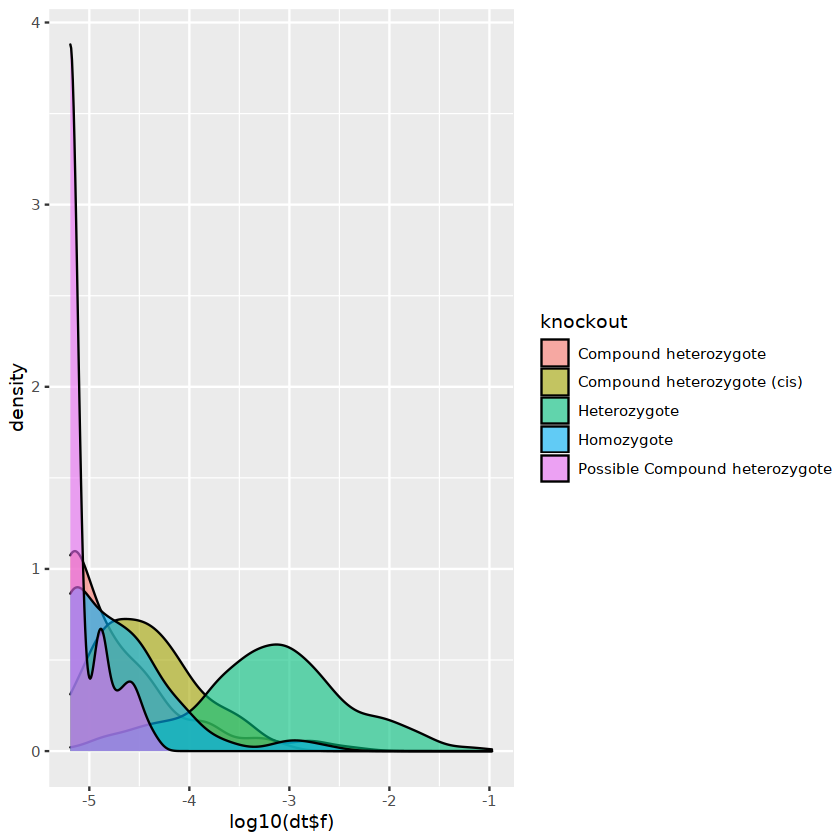

In [43]:
ggplot(dt, aes(x=log10(dt$f), fill = knockout)) +
    geom_density(alpha = 0.6)

In [34]:
categories <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/gnomad/karczewski2020/supplementary_dataset_11_full_constraint_metrics.tsv")
categories <- categories[categories$canonical, ]

In [35]:
categories

gene,transcript,canonical,obs_mis,exp_mis,oe_mis,mu_mis,possible_mis,obs_mis_pphen,exp_mis_pphen,⋯,gene_type,gene_length,exac_pLI,exac_obs_lof,exac_exp_lof,exac_oe_lof,brain_expression,chromosome,start_position,end_position
<chr>,<chr>,<lgl>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,⋯,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<lgl>,<chr>,<int>,<int>
A1BG,ENST00000263100,TRUE,298,293.850,1.01410,1.8787e-05,3115,104,101.390,⋯,protein_coding,8322,9.0649e-05,8,12.3010,0.650330,NA,19,58856544,58864865
A1CF,ENST00000373995,TRUE,274,324.180,0.84521,1.5919e-05,3829,100,138.390,⋯,protein_coding,86267,3.6197e-03,9,25.9370,0.347000,NA,10,52559169,52645435
A2M,ENST00000318602,TRUE,627,773.450,0.81065,4.0409e-05,9524,109,167.800,⋯,protein_coding,48566,5.4011e-04,16,51.7060,0.309440,NA,12,9220260,9268825
A2ML1,ENST00000299698,TRUE,766,791.900,0.96729,4.1418e-05,9472,183,202.780,⋯,protein_coding,64530,1.3290e-22,42,56.0650,0.749140,NA,12,8975068,9039597
A3GALT2,ENST00000442999,TRUE,170,171.710,0.99002,1.0999e-05,2110,41,38.657,⋯,protein_coding,14333,6.5030e-07,9,8.0167,1.122700,NA,1,33772367,33786699
A4GALT,ENST00000401850,TRUE,241,232.950,1.03450,1.7604e-05,2248,71,78.116,⋯,protein_coding,29178,1.1160e-01,2,4.9005,0.408120,NA,22,43088127,43117304
A4GNT,ENST00000236709,TRUE,179,188.070,0.95177,1.0058e-05,2239,50,57.242,⋯,protein_coding,8670,5.9841e-01,1,6.8105,0.146830,NA,3,137842560,137851229
AAAS,ENST00000209873,TRUE,316,298.370,1.05910,1.7472e-05,3476,80,77.742,⋯,protein_coding,17409,4.5429e-10,19,28.1510,0.674940,NA,12,53701240,53718648
AACS,ENST00000316519,TRUE,397,408.390,0.97211,2.4112e-05,4402,132,140.780,⋯,protein_coding,77949,4.2457e-12,20,24.1550,0.827980,NA,12,125549925,125627873
